# MSA Benchmarking: Statistical Analysis

Reads `results/results.csv` (7 aligners × 386 BAliBASE 3.0 problems) and produces:

**Accuracy tables:** overall summary, SP/TC by reference set  
**Statistical tests:** pairwise Wilcoxon, Cliff's delta, Friedman, Kendall's W, Bonferroni/BH correction, Nemenyi CD  
**Visualisations:** box plots, heatmaps, violin plots, Pareto, runtime CDF, parallel coordinates, win matrix, Δ SP heatmap  
**Scaling analysis:** runtime and memory vs sequence count and length  
**Robustness:** bootstrap 95% CIs (overall and per reference set), failure analysis

## Imports & Configuration

In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

PROJECT_DIR = Path(r'C:\Users\anand\Desktop\SEM 4\CS 502\Project')
BB3_DIR     = PROJECT_DIR / 'data' / 'bb3_release'
CSV_PATH    = PROJECT_DIR / 'results' / 'results.csv'
FIG_DIR     = PROJECT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# â”€â”€ Aligner keys (must match 02_benchmark.ipynb) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ALIGNERS = ['mafft_fftns2', 'mafft_linsi', 'muscle5', 'clustalo', 'kalign3', 't_coffee', 'famsa']

# â”€â”€ Style â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {
    'mafft_fftns2': '#4C72B0',
    'mafft_linsi':  '#DD8452',
    'muscle5':      '#55A868',
    'clustalo':     '#C44E52',
    'kalign3':      '#8172B2',
    't_coffee':     '#937860',
    'famsa':        '#DA8BC3',
}
ALIGNER_LABELS = {
    'mafft_fftns2': 'MAFFT FFT-NS-2',
    'mafft_linsi':  'MAFFT L-INS-i',
    'muscle5':      'MUSCLE5',
    'clustalo':     'Clustal Omega',
    'kalign3':      'Kalign3',
    't_coffee':     'T-Coffee',
    'famsa':        'FAMSA',
}
RV_SETS = ['RV11', 'RV12', 'RV20', 'RV30', 'RV40', 'RV50']

df_raw = pd.read_csv(CSV_PATH)
df = df_raw[df_raw['success'] == True].copy()
df['aligner_label'] = df['aligner'].map(ALIGNER_LABELS)

print(f'Loaded {len(df_raw)} rows, {len(df)} successful runs.')
df.head(3)

Loaded 2702 rows, 2658 successful runs.


,rv_set,problem,aligner,sp_score,tc_score,runtime_sec,peak_mem_mb,success,aligner_label
0,RV11,BB11001,clustalo,0.907407,0.829545,0.117988,6.375000,True,Clustal Omega
1,RV12,BBS12044,mafft_linsi,0.850680,0.629403,0.975839,16.250000,True,MAFFT L-INS-i
2,RV12,BBS12044,t_coffee,0.878733,0.638591,8.354027,536.925781,True,T-Coffee


## Tool Versions & Run Configuration

Exact versions used in this benchmark, as required by computational benchmarking best practices (Weber et al., *Genome Biology* 2019).

In [2]:
import subprocess

def wsl_version(cmd):
    try:
        r = subprocess.run(['wsl', '-e', 'bash', '-c', cmd],
                           capture_output=True, text=True, timeout=10)
        return (r.stdout + r.stderr).strip().split('\n')[0]
    except Exception as e:
        return str(e)

version_info = {
    'MAFFT':        wsl_version('mafft --version 2>&1'),
    'MUSCLE5':      wsl_version('muscle --version 2>&1'),
    'Clustal Omega':wsl_version('clustalo --version 2>&1'),
    'Kalign3':      wsl_version('kalign --version 2>&1'),
    'T-Coffee':     wsl_version('t_coffee --version 2>&1 | head -1'),
    'FAMSA':        wsl_version('famsa --version 2>&1 | head -2 | tail -1'),
    'Python':       wsl_version('python3 --version 2>&1'),
    'BioPython':    wsl_version('python3 -c "import Bio; print(Bio.__version__)"'),
}

print('=== Tool Versions ===')
for tool, ver in version_info.items():
    print(f'  {tool:<18} {ver}')

print()
print('=== Run Configuration ===')
print('  All aligners run with default parameters (no flags changed from defaults).')
print('  Timeout: 120 s per alignment (T-Coffee on large problems).')
print('  Threads: default (each aligner chooses its own default thread count).')
print()
print('  Note: T-Coffee (v13.41) was originally developed using BAliBASE as a')
print('  training benchmark. SP/TC scores for T-Coffee should be interpreted with')
print('  this in mind (Aniba et al. 2010, PMID 20169166).')


=== Tool Versions ===
  MAFFT              v7.505 (2022/Apr/10)
  MUSCLE5            muscle 5.3.linux64 [d9725ac]
  Clustal Omega      1.2.4
  Kalign3            kalign 3.3.5
  T-Coffee           
  FAMSA              
  Python             Python 3.12.3
  BioPython          1.87

=== Run Configuration ===
  All aligners run with default parameters (no flags changed from defaults).
  Timeout: 120 s per alignment (T-Coffee on large problems).
  Threads: default (each aligner chooses its own default thread count).

  Note: T-Coffee (v13.41) was originally developed using BAliBASE as a
  training benchmark. SP/TC scores for T-Coffee should be interpreted with
  this in mind (Aniba et al. 2010, PMID 20169166).


## Overall Summary

In [3]:
summary = (
    df.groupby('aligner')
    .agg(
        n_problems=('sp_score', 'count'),
        sp_mean=('sp_score',    'mean'),
        sp_std=('sp_score',     'std'),
        tc_mean=('tc_score',    'mean'),
        tc_std=('tc_score',     'std'),
        runtime_median=('runtime_sec', 'median'),
        runtime_mean=('runtime_sec',   'mean'),
        mem_median=('peak_mem_mb',     'median'),
    )
    .round(4)
    .rename(index=ALIGNER_LABELS)
)

print('=== Overall Summary ===')
display(summary)
summary.to_csv(PROJECT_DIR / 'results' / 'table_summary.csv')

=== Overall Summary ===


,n_problems,sp_mean,sp_std,tc_mean,tc_std,runtime_median,runtime_mean,mem_median
aligner,,,,,,,,
Clustal Omega,386,0.7178,0.2013,0.3625,0.2404,0.6358,1.6741,16.2793
FAMSA,386,0.7184,0.1992,0.3570,0.2565,0.1852,0.4043,17.1250
Kalign3,385,0.6921,0.2092,0.3223,0.2448,0.0601,0.0736,5.2500
MAFFT FFT-NS-2,386,0.6883,0.2048,0.3151,0.2327,0.5510,0.6125,23.2773
MAFFT L-INS-i,386,0.7425,0.1878,0.3785,0.2378,0.8759,4.3785,13.4375
MUSCLE5,386,0.7614,0.1735,0.3986,0.2452,0.5200,3.9156,112.4941
T-Coffee,342,0.7455,0.1821,0.3943,0.2483,5.2968,17.4008,512.0391


## Stratified Results by Reference Set

In [4]:
strat = (
    df.groupby(['rv_set', 'aligner'])
    .agg(sp_mean=('sp_score', 'mean'),
         tc_mean=('tc_score', 'mean'),
         runtime_median=('runtime_sec', 'median'))
    .round(4)
)
strat.index = strat.index.set_levels(
    [ALIGNER_LABELS.get(a, a) for a in strat.index.get_level_values('aligner').unique()],
    level='aligner'
)

# Pivot for a readable view: rows = RV set, columns = aligner
sp_pivot = strat['sp_mean'].unstack('aligner').round(4)
tc_pivot = strat['tc_mean'].unstack('aligner').round(4)

print('=== SP Score by Reference Set ===' )
display(sp_pivot)
print('\n=== TC Score by Reference Set ===')
display(tc_pivot)

sp_pivot.to_csv(PROJECT_DIR / 'results' / 'table_sp_by_rv.csv')
tc_pivot.to_csv(PROJECT_DIR / 'results' / 'table_tc_by_rv.csv')

=== SP Score by Reference Set ===


aligner,Clustal Omega,FAMSA,Kalign3,MAFFT FFT-NS-2,MAFFT L-INS-i,MUSCLE5,T-Coffee
rv_set,,,,,,,
RV11,0.4833,0.5104,0.4522,0.4309,0.5315,0.6051,0.5725
RV12,0.8226,0.8348,0.8110,0.7980,0.8446,0.8570,0.8589
RV20,0.8371,0.8325,0.8204,0.8190,0.8514,0.8527,0.8437
RV30,0.7502,0.7319,0.7194,0.7307,0.7691,0.7769,0.7495
RV40,0.6624,0.6429,0.6257,0.6189,0.6704,0.6673,0.6637
RV50,0.7039,0.6890,0.6482,0.6891,0.7448,0.7510,0.7498



=== TC Score by Reference Set ===


aligner,Clustal Omega,FAMSA,Kalign3,MAFFT FFT-NS-2,MAFFT L-INS-i,MUSCLE5,T-Coffee
rv_set,,,,,,,
RV11,0.2538,0.2763,0.2178,0.1993,0.2855,0.3541,0.3183
RV12,0.6081,0.6386,0.5816,0.5625,0.6304,0.6507,0.6494
RV20,0.3092,0.2807,0.2582,0.2508,0.3169,0.3263,0.3088
RV30,0.3598,0.3168,0.3157,0.3132,0.3748,0.3805,0.3698
RV40,0.2253,0.2068,0.1885,0.1862,0.2171,0.2075,0.2110
RV50,0.2952,0.2725,0.2322,0.2741,0.3161,0.3204,0.3317


## Pairwise Wilcoxon Tests
Tests whether differences in SP and TC scores between aligner pairs are significant (Î± = 0.05). Uses matched pairs (same problem), so only problems attempted by both aligners are included.

In [5]:
def cliffs_delta(x, y):
    """Compute Cliff's delta effect size between arrays x and y."""
    x, y = np.asarray(x), np.asarray(y)
    more = sum(xi > yj for xi in x for yj in y)
    less = sum(xi < yj for xi in x for yj in y)
    return (more - less) / (len(x) * len(y))

def cliffs_delta_magnitude(d):
    """Interpret Cliff's delta magnitude."""
    d = abs(d)
    if d < 0.147:  return 'negligible'
    if d < 0.330:  return 'small'
    if d < 0.474:  return 'medium'
    return 'large'

stat_rows = []

for metric in ['sp_score', 'tc_score']:
    # Pivot to wide format so we can extract matched pairs
    wide = df.pivot_table(index='problem', columns='aligner', values=metric)

    for a1, a2 in combinations(ALIGNERS, 2):
        if a1 not in wide.columns or a2 not in wide.columns:
            continue
        paired = wide[[a1, a2]].dropna()
        if len(paired) < 5:
            continue

        stat, pval = stats.wilcoxon(paired[a1], paired[a2], alternative='two-sided')
        delta      = cliffs_delta(paired[a1].values, paired[a2].values)
        stat_rows.append({
            'metric':      metric,
            'aligner_1':   ALIGNER_LABELS[a1],
            'aligner_2':   ALIGNER_LABELS[a2],
            'n_pairs':     len(paired),
            'W_stat':      round(stat, 2),
            'p_value':     round(pval, 6),
            'significant': pval < 0.05,
            'cliffs_delta': round(delta, 4),
            'effect_size': cliffs_delta_magnitude(delta),
        })

df_stats = pd.DataFrame(stat_rows)
print("=== Wilcoxon Tests + Cliff's Delta ===")
display(df_stats)
df_stats.to_csv(PROJECT_DIR / 'results' / 'table_wilcoxon.csv', index=False)

=== Wilcoxon Tests + Cliff's Delta ===


,metric,aligner_1,aligner_2,n_pairs,W_stat,p_value,significant,cliffs_delta,effect_size
0,sp_score,MAFFT FFT-NS-2,MAFFT L-INS-i,386,2671.0,0.000000,True,-0.1697,small
1,sp_score,MAFFT FFT-NS-2,MUSCLE5,386,1324.0,0.000000,True,-0.2215,small
2,sp_score,MAFFT FFT-NS-2,Clustal Omega,386,11052.0,0.000000,True,-0.1010,negligible
3,sp_score,MAFFT FFT-NS-2,Kalign3,385,35388.0,0.524428,False,-0.0186,negligible
4,sp_score,MAFFT FFT-NS-2,T-Coffee,342,2057.0,0.000000,True,-0.1959,small
5,sp_score,MAFFT FFT-NS-2,FAMSA,386,14720.0,0.000000,True,-0.0987,negligible
6,sp_score,MAFFT L-INS-i,MUSCLE5,386,21270.0,0.000000,True,-0.0528,negligible
7,sp_score,MAFFT L-INS-i,Clustal Omega,386,15730.5,0.000000,True,0.0672,negligible
8,sp_score,MAFFT L-INS-i,Kalign3,385,6817.0,0.000000,True,0.1489,small
9,sp_score,MAFFT L-INS-i,T-Coffee,342,22784.5,0.000470,True,-0.0229,negligible


## Accuracy Distribution — Box Plots

C:\Users\anand\AppData\Local\Temp\ipykernel_25964\3925154748.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\anand\AppData\Local\Temp\ipykernel_25964\3925154748.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


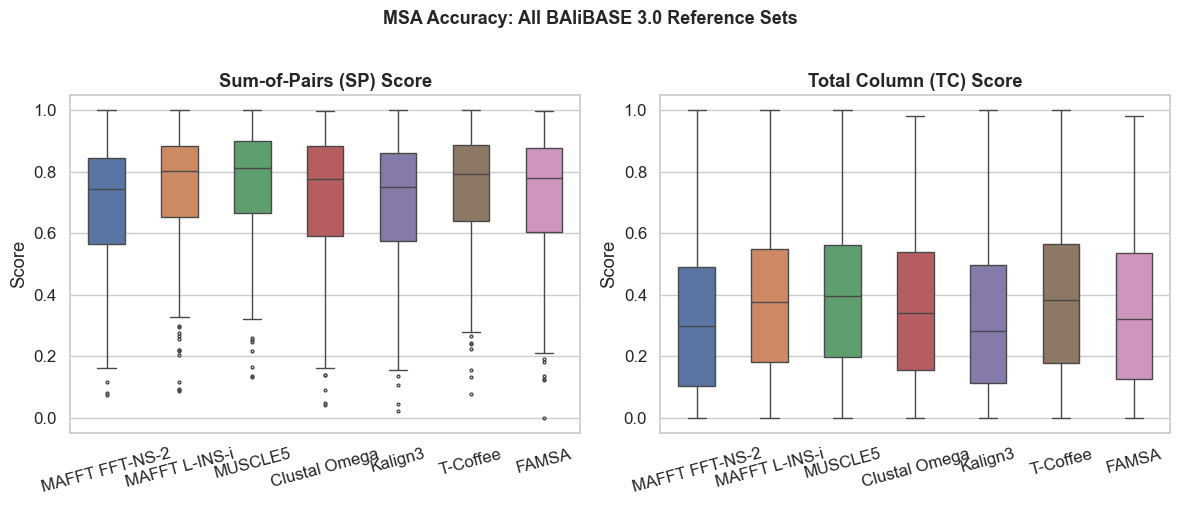

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = list(ALIGNER_LABELS.values())

for ax, metric, title in zip(axes,
                              ['sp_score', 'tc_score'],
                              ['Sum-of-Pairs (SP) Score', 'Total Column (TC) Score']):
    sns.boxplot(
        data=df, x='aligner_label', y=metric,
        order=order,
        palette=list(PALETTE.values()),
        width=0.5, fliersize=2, ax=ax
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score')
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('MSA Accuracy: All BAliBASE 3.0 Reference Sets', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig1_accuracy_overall.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig1_accuracy_overall.png', dpi=150, bbox_inches='tight')
plt.show()

## SP Score by Reference Set

C:\Users\anand\AppData\Local\Temp\ipykernel_25964\4121856126.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\anand\AppData\Local\Temp\ipykernel_25964\4121856126.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\anand\AppData\Local\Temp\ipykernel_25964\4121856126.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\anand\AppData\Local\Temp\ipykernel_25964\4121856126.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

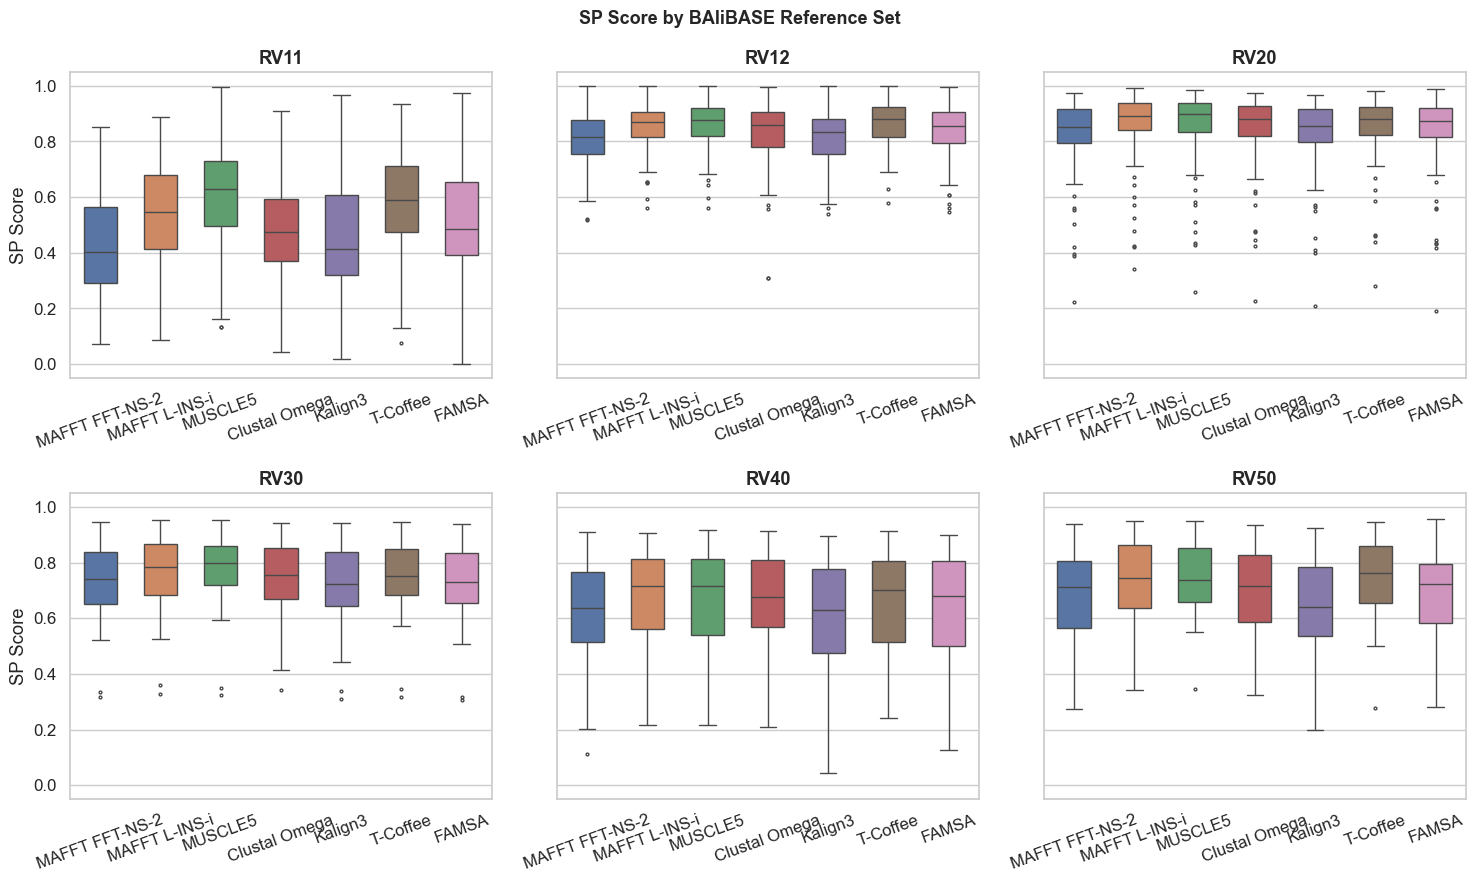

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

for ax, rv in zip(axes.flat, RV_SETS):
    subset = df[df['rv_set'] == rv]
    if subset.empty:
        ax.set_title(f'{rv} (no data)')
        continue
    sns.boxplot(
        data=subset, x='aligner_label', y='sp_score',
        order=order, palette=list(PALETTE.values()),
        width=0.55, fliersize=2, ax=ax
    )
    ax.set_title(rv, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('SP Score' if ax in axes[:, 0] else '')
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('SP Score by BAliBASE Reference Set', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig2_sp_by_rvset.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig2_sp_by_rvset.png', dpi=150, bbox_inches='tight')
plt.show()

## Runtime Distribution

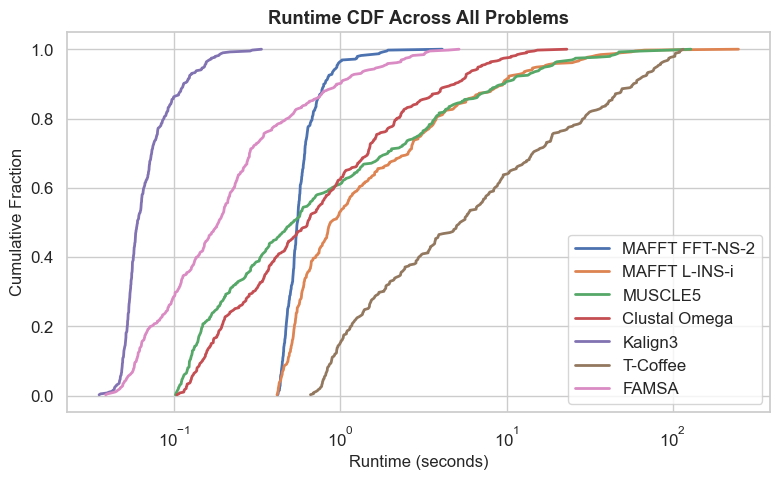

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

for aligner_key, label in ALIGNER_LABELS.items():
    vals = df[df['aligner'] == aligner_key]['runtime_sec'].dropna()
    if vals.empty:
        continue
    vals_sorted = np.sort(vals)
    cdf = np.arange(1, len(vals_sorted) + 1) / len(vals_sorted)
    ax.plot(vals_sorted, cdf, label=label, color=PALETTE[aligner_key], linewidth=2)

ax.set_xlabel('Runtime (seconds)', fontsize=12)
ax.set_ylabel('Cumulative Fraction', fontsize=12)
ax.set_title('Runtime CDF Across All Problems', fontweight='bold')
ax.legend()
ax.set_xscale('log')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig3_runtime_cdf.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig3_runtime_cdf.png', dpi=150, bbox_inches='tight')
plt.show()

## Speed–Accuracy Pareto

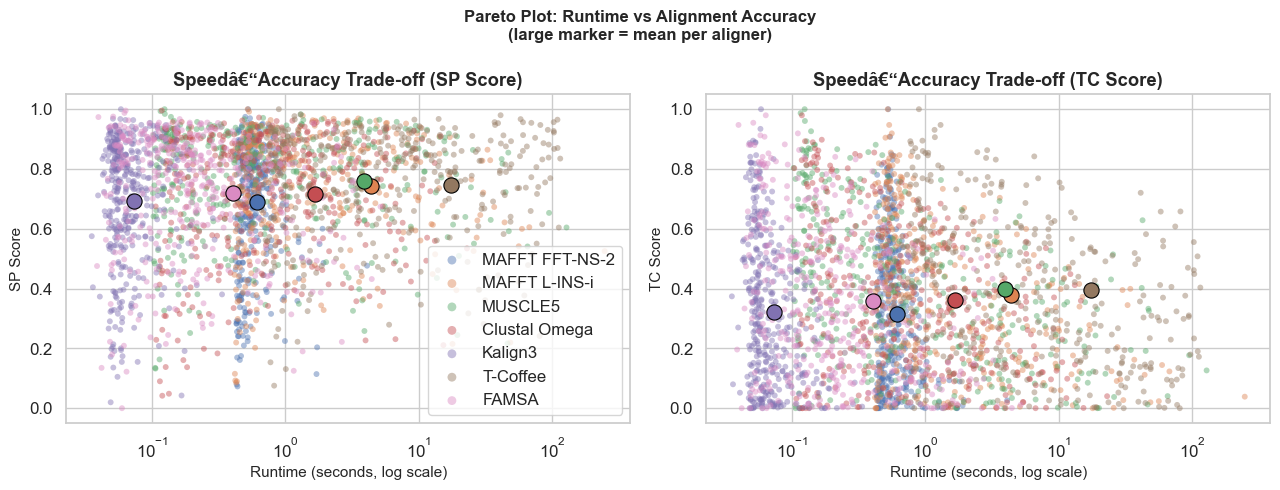

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, label in zip(axes, ['sp_score', 'tc_score'], ['SP Score', 'TC Score']):
    for aligner_key, aligner_label in ALIGNER_LABELS.items():
        sub = df[df['aligner'] == aligner_key][['runtime_sec', metric]].dropna()
        if sub.empty:
            continue
        ax.scatter(
            sub['runtime_sec'], sub[metric],
            label=aligner_label,
            color=PALETTE[aligner_key],
            alpha=0.45, s=18, edgecolors='none'
        )
        # Mark the mean as a larger marker
        ax.scatter(
            sub['runtime_sec'].mean(), sub[metric].mean(),
            color=PALETTE[aligner_key], s=120,
            edgecolors='black', linewidths=0.8, zorder=5
        )

    ax.set_xscale('log')
    ax.set_xlabel('Runtime (seconds, log scale)', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'Speedâ€“Accuracy Trade-off ({label})', fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    if ax == axes[0]:
        ax.legend(markerscale=1.5)

fig.suptitle('Pareto Plot: Runtime vs Alignment Accuracy\n(large marker = mean per aligner)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig4_pareto.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig4_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

## SP Score Heatmap (Aligner × Reference Set)

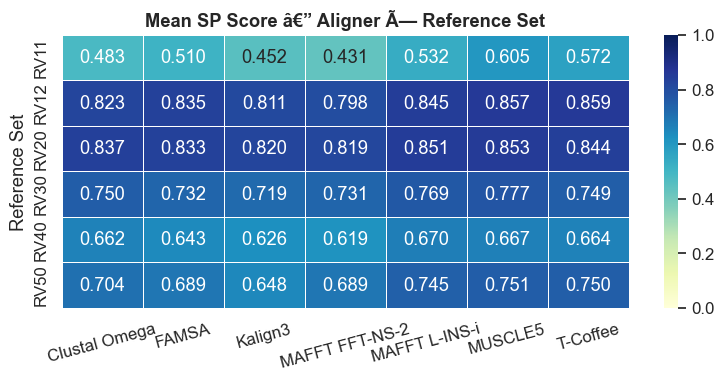

In [10]:
heat_data = (
    df.groupby(['rv_set', 'aligner'])['sp_score']
    .mean()
    .unstack('aligner')
    .rename(columns=ALIGNER_LABELS)
    .reindex(RV_SETS)
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    heat_data, annot=True, fmt='.3f',
    cmap='YlGnBu', vmin=0, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Mean SP Score â€” Aligner Ã— Reference Set', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Reference Set')
plt.xticks(rotation=15)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig5_heatmap_sp.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig5_heatmap_sp.png', dpi=150, bbox_inches='tight')
plt.show()

## Output Summary

In [11]:
for f in sorted((PROJECT_DIR / 'results').glob('*.csv')):
    print(f'  results/{f.name}')
figs = sorted(FIG_DIR.glob('*.png'))
print(f'\nFigures : {len(figs)}')
for f in figs:
    print(f'  figures/{f.name}')
print(f'\nTables  : {len(list((PROJECT_DIR / "results").glob("*.csv")))}')


  results/results.csv
  results/results_oxbench.csv
  results/results_prefab4.csv
  results/results_sabre.csv
  results/table_nemenyi_sp.csv
  results/table_sp_by_rv.csv
  results/table_summary.csv
  results/table_tc_by_rv.csv
  results/table_wilcoxon.csv
  results/table_wilcoxon_corrected.csv
  results/table_wilcoxon_runtime.csv

Figures : 21
  figures/fig10_pvalue_heatmap.png
  figures/fig11_bootstrap_ci.png
  figures/fig12_win_matrix.png
  figures/fig13_avg_rank.png
  figures/fig14_cd_diagram.png
  figures/fig15_parallel_coords.png
  figures/fig16_scaling_plots.png
  figures/fig17_score_vs_size.png
  figures/fig18_delta_sp_heatmap.png
  figures/fig19_bootstrap_ci_per_rv.png
  figures/fig1_accuracy_overall.png
  figures/fig20_nemenyi_heatmap.png
  figures/fig21_score_vs_identity.png
  figures/fig2_sp_by_rvset.png
  figures/fig3_runtime_cdf.png
  figures/fig4_pareto.png
  figures/fig5_heatmap_sp.png
  figures/fig6_heatmap_tc.png
  figures/fig7_memory_boxplot.png
  figures/fig8_sp_vs_t

---
## TC Score Heatmap

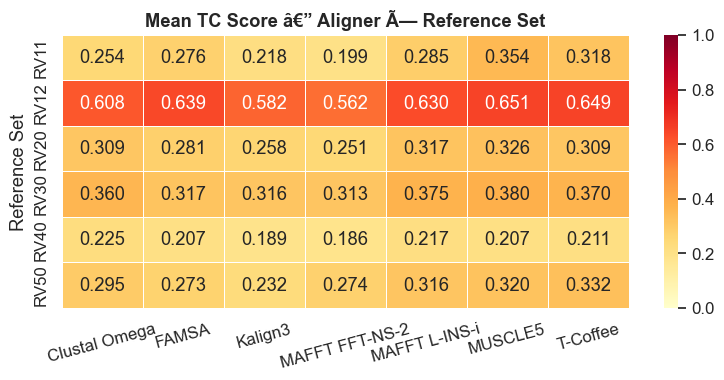

In [12]:
tc_heat = (
    df.groupby(['rv_set', 'aligner'])['tc_score']
    .mean()
    .unstack('aligner')
    .rename(columns=ALIGNER_LABELS)
    .reindex(RV_SETS)
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(tc_heat, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Mean TC Score â€” Aligner Ã— Reference Set', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Reference Set')
plt.xticks(rotation=15)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig6_heatmap_tc.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig6_heatmap_tc.png', dpi=150, bbox_inches='tight')
plt.show()

## Memory Usage

C:\Users\anand\AppData\Local\Temp\ipykernel_25964\92413226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


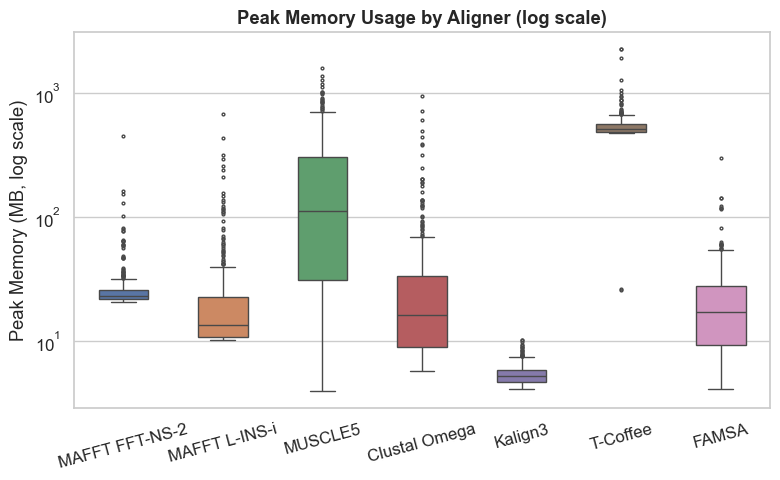

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df, x='aligner_label', y='peak_mem_mb',
    order=list(ALIGNER_LABELS.values()),
    palette=list(PALETTE.values()),
    width=0.5, fliersize=2, ax=ax
)
ax.set_yscale('log')
ax.set_title('Peak Memory Usage by Aligner (log scale)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Peak Memory (MB, log scale)')
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig7_memory_boxplot.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig7_memory_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## SP vs TC Correlation

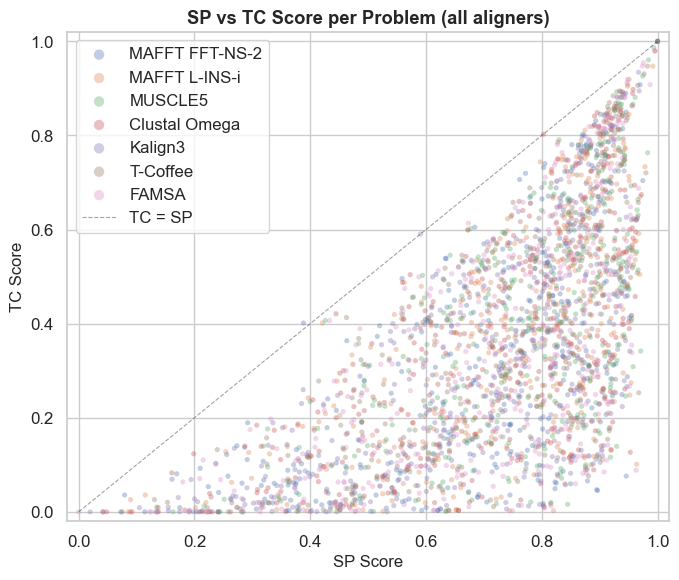

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
for key, label in ALIGNER_LABELS.items():
    sub = df[df['aligner'] == key]
    ax.scatter(sub['sp_score'], sub['tc_score'],
               label=label, color=PALETTE[key],
               alpha=0.35, s=14, edgecolors='none')

# Diagonal reference line (TC = SP)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4, label='TC = SP')
ax.set_xlabel('SP Score', fontsize=12)
ax.set_ylabel('TC Score', fontsize=12)
ax.set_title('SP vs TC Score per Problem (all aligners)', fontweight='bold')
ax.legend(markerscale=2)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig8_sp_vs_tc_scatter.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig8_sp_vs_tc_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Score Distributions — Violin Plots

C:\Users\anand\AppData\Local\Temp\ipykernel_25964\769478317.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='aligner_label', y=metric, order=order,
C:\Users\anand\AppData\Local\Temp\ipykernel_25964\769478317.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='aligner_label', y=metric, order=order,


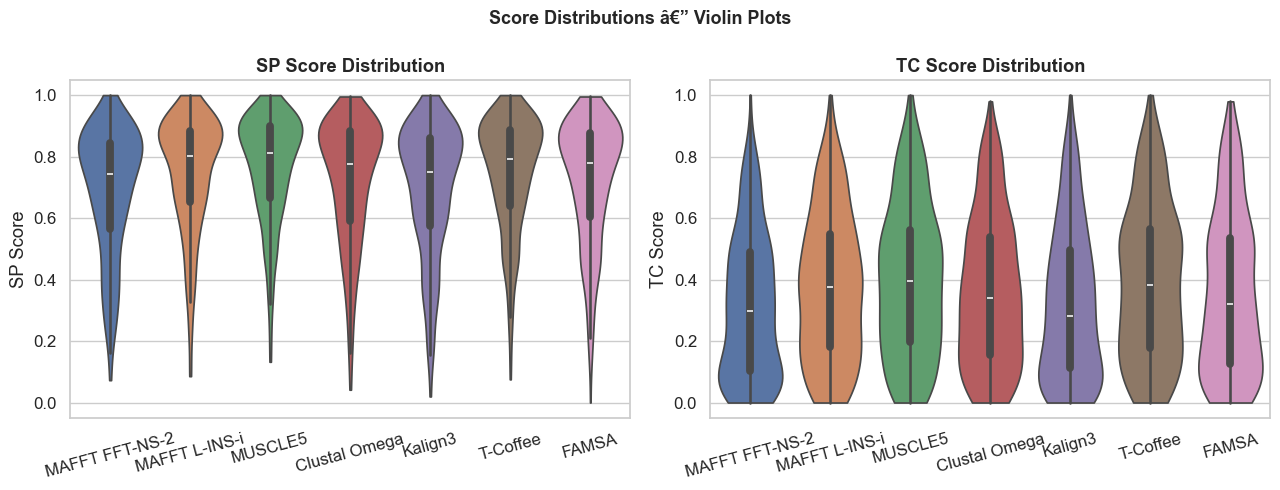

In [15]:
order = list(ALIGNER_LABELS.values())
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title in zip(axes,
                              ['sp_score', 'tc_score'],
                              ['SP Score', 'TC Score']):
    sns.violinplot(data=df, x='aligner_label', y=metric, order=order,
                   palette=list(PALETTE.values()),
                   inner='box', cut=0, ax=ax)
    ax.set_title(f'{title} Distribution', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(title)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Score Distributions â€” Violin Plots', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig9_violin_plots.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig9_violin_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Pairwise Significance Heatmap

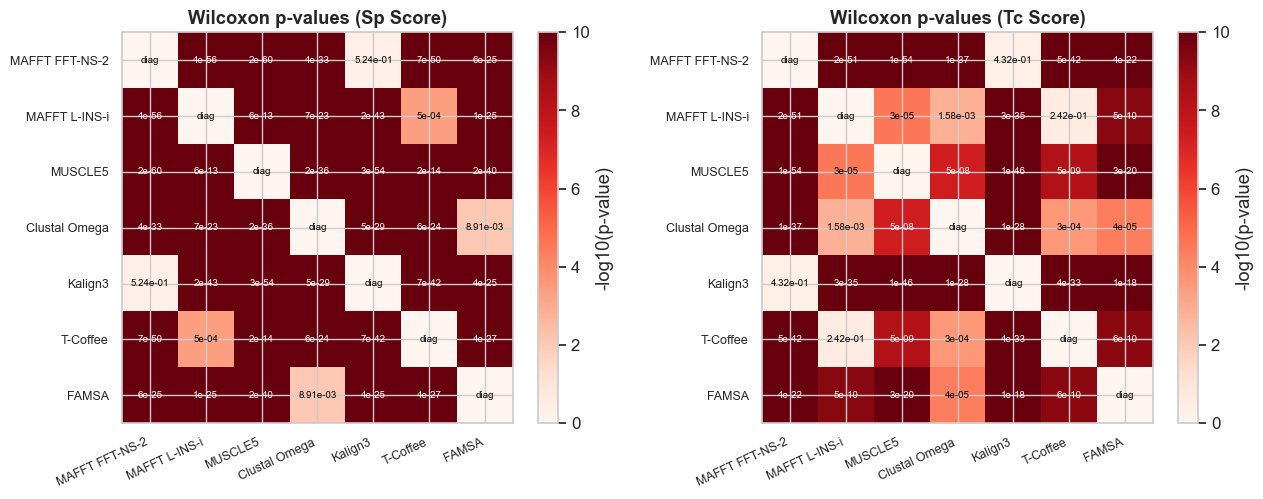

In [16]:
import matplotlib.colors as mcolors

labels_order = [ALIGNER_LABELS[a] for a in ALIGNERS]
n = len(labels_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['sp_score', 'tc_score']):
    mat = np.full((n, n), np.nan)
    wide = df.pivot_table(index='problem', columns='aligner', values=metric)

    for i, a1 in enumerate(ALIGNERS):
        for j, a2 in enumerate(ALIGNERS):
            if i == j:
                mat[i, j] = 1.0
                continue
            if a1 not in wide.columns or a2 not in wide.columns:
                continue
            paired = wide[[a1, a2]].dropna()
            _, pval = stats.wilcoxon(paired[a1], paired[a2], alternative='two-sided')
            mat[i, j] = pval

    # -log10(p), cap at 10
    with np.errstate(divide='ignore'):
        log_mat = np.where(np.eye(n, dtype=bool), 0, -np.log10(np.clip(mat, 1e-10, 1)))

    im = ax.imshow(log_mat, cmap='Reds', vmin=0, vmax=10)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(labels_order, rotation=25, ha='right', fontsize=9)
    ax.set_yticklabels(labels_order, fontsize=9)
    for i in range(n):
        for j in range(n):
            val = mat[i, j]
            txt = 'diag' if i == j else (f'{val:.2e}' if val >= 0.001 else f'{val:.0e}')
            ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                    color='white' if log_mat[i, j] > 6 else 'black')
    plt.colorbar(im, ax=ax, label='-log10(p-value)')
    ax.set_title(f'Wilcoxon p-values ({metric.replace("_"," ").title()})', fontweight='bold')

fig.tight_layout()
fig.savefig(FIG_DIR / 'fig10_pvalue_heatmap.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig10_pvalue_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Friedman Test, Kendall's W & Multiple-Comparison Correction

Friedman ranks all aligners simultaneously, avoiding Type I inflation from repeated Wilcoxon tests. Kendall's W is the accompanying effect size (0–1 scale). Bonferroni and BH corrections are then applied to the pairwise p-values.

In [17]:
from scipy.stats import friedmanchisquare
from statsmodels.stats.multitest import multipletests

wide_sp = df.pivot_table(index='problem', columns='aligner', values='sp_score').dropna()
wide_tc = df.pivot_table(index='problem', columns='aligner', values='tc_score').dropna()

print("=== Friedman Test + Kendall's W ===")
for metric_name, wide in [('SP Score', wide_sp), ('TC Score', wide_tc)]:
    avail      = [a for a in ALIGNERS if a in wide.columns]
    stat, p    = friedmanchisquare(*[wide[a].values for a in avail])
    k, N       = len(avail), len(wide)
    W          = stat / (N * (k - 1))   # Kendall's W (0 = no concordance, 1 = perfect)
    magnitude  = ('weak' if W < 0.1 else 'moderate' if W < 0.3
                  else 'strong' if W < 0.5 else 'very strong')
    print(f'  {metric_name}: χ²={stat:.2f}, p={p:.2e}, N={N}, k={k}')
    print(f"  Kendall's W = {W:.4f}  ({magnitude} concordance)\n")

# Bonferroni and Benjamini–Hochberg correction on the pairwise Wilcoxon p-values
sp_rows          = df_stats[df_stats['metric'] == 'sp_score'].copy()
raw_p            = sp_rows['p_value'].values
_, p_bonf, _, _  = multipletests(raw_p, method='bonferroni')
_, p_bh,   _, _  = multipletests(raw_p, method='fdr_bh')

sp_rows = sp_rows.copy()
sp_rows['p_bonferroni'] = p_bonf.round(6)
sp_rows['p_bh']         = p_bh.round(6)
sp_rows['sig_bonf']     = p_bonf < 0.05
sp_rows['sig_bh']       = p_bh   < 0.05

print('Corrected p-values (SP Score):')
display(sp_rows[['aligner_1', 'aligner_2', 'p_value', 'p_bonferroni',
                 'p_bh', 'sig_bonf', 'sig_bh']].reset_index(drop=True))
sp_rows.to_csv(PROJECT_DIR / 'results' / 'table_wilcoxon_corrected.csv', index=False)


=== Friedman Test + Kendall's W ===
  SP Score: χ²=935.73, p=7.07e-199, N=341, k=7
  Kendall's W = 0.4573  (strong concordance)

  TC Score: χ²=618.93, p=1.93e-130, N=341, k=7
  Kendall's W = 0.3025  (strong concordance)

Corrected p-values (SP Score):


,aligner_1,aligner_2,p_value,p_bonferroni,p_bh,sig_bonf,sig_bh
0,MAFFT FFT-NS-2,MAFFT L-INS-i,0.000000,0.000000,0.000000,True,True
1,MAFFT FFT-NS-2,MUSCLE5,0.000000,0.000000,0.000000,True,True
2,MAFFT FFT-NS-2,Clustal Omega,0.000000,0.000000,0.000000,True,True
3,MAFFT FFT-NS-2,Kalign3,0.524428,1.000000,0.524428,False,False
4,MAFFT FFT-NS-2,T-Coffee,0.000000,0.000000,0.000000,True,True
5,MAFFT FFT-NS-2,FAMSA,0.000000,0.000000,0.000000,True,True
6,MAFFT L-INS-i,MUSCLE5,0.000000,0.000000,0.000000,True,True
7,MAFFT L-INS-i,Clustal Omega,0.000000,0.000000,0.000000,True,True
8,MAFFT L-INS-i,Kalign3,0.000000,0.000000,0.000000,True,True
9,MAFFT L-INS-i,T-Coffee,0.000470,0.009870,0.000519,True,True


## Spearman Rank Correlation: SP vs TC

Checks whether both metrics rank aligners and problems consistently. High ρ means SP and TC agree on which problems are easy or hard for a given tool.

In [18]:
corr_rows = []
for key, label in ALIGNER_LABELS.items():
    sub = df[df['aligner'] == key][['sp_score', 'tc_score']].dropna()
    rho, p = stats.spearmanr(sub['sp_score'], sub['tc_score'])
    corr_rows.append({'aligner': label, 'rho': round(rho, 4),
                      'p_value': round(p, 6), 'n': len(sub)})

df_spearman = pd.DataFrame(corr_rows)
print("Spearman ρ between SP and TC scores per aligner:")
display(df_spearman)


Spearman ρ between SP and TC scores per aligner:


,aligner,rho,p_value,n
0,MAFFT FFT-NS-2,0.6379,0.0,386
1,MAFFT L-INS-i,0.6430,0.0,386
2,MUSCLE5,0.6503,0.0,386
3,Clustal Omega,0.6935,0.0,386
4,Kalign3,0.6888,0.0,385
5,T-Coffee,0.6759,0.0,342
6,FAMSA,0.6637,0.0,386


## Bootstrap 95% CIs on Mean SP

Bootstrap 95% CIs on mean SP score:


,aligner,sp_mean,ci_lo,ci_hi
0,MAFFT FFT-NS-2,0.6883,0.6672,0.7082
1,MAFFT L-INS-i,0.7425,0.7232,0.7618
2,MUSCLE5,0.7614,0.7434,0.7785
3,Clustal Omega,0.7178,0.6975,0.7376
4,Kalign3,0.6921,0.6702,0.7121
5,T-Coffee,0.7455,0.7262,0.7647
6,FAMSA,0.7184,0.6968,0.7372


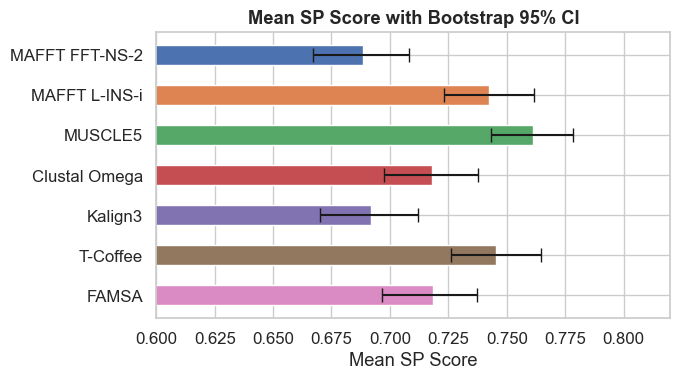

In [19]:
rng = np.random.default_rng(42)
N_BOOT = 2000

boot_rows = []
for key, label in ALIGNER_LABELS.items():
    scores = df[df['aligner'] == key]['sp_score'].dropna().values
    means  = [rng.choice(scores, size=len(scores), replace=True).mean()
              for _ in range(N_BOOT)]
    lo, hi = np.percentile(means, [2.5, 97.5])
    boot_rows.append({'aligner': label,
                      'sp_mean': scores.mean().round(4),
                      'ci_lo':   round(lo, 4),
                      'ci_hi':   round(hi, 4)})

df_boot = pd.DataFrame(boot_rows)
print('Bootstrap 95% CIs on mean SP score:')
display(df_boot)

# Plot with error bars
fig, ax = plt.subplots(figsize=(7, 4))
colors_list = list(PALETTE.values())
for i, row in df_boot.iterrows():
    ax.barh(row['aligner'], row['sp_mean'],
            xerr=[[row['sp_mean'] - row['ci_lo']], [row['ci_hi'] - row['sp_mean']]],
            color=colors_list[i], capsize=5, height=0.5)
ax.set_xlabel('Mean SP Score')
ax.set_title('Mean SP Score with Bootstrap 95% CI', fontweight='bold')
ax.set_xlim(0.6, 0.82)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig11_bootstrap_ci.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig11_bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()

## Win / Tie / Loss Matrix

Win/Tie/Loss for SP score (row aligner vs column aligner):


,A,B,Win,Tie,Loss
0,MAFFT FFT-NS-2,MAFFT L-INS-i,21,1,364
1,MAFFT FFT-NS-2,MUSCLE5,19,1,366
2,MAFFT FFT-NS-2,Clustal Omega,77,0,309
3,MAFFT FFT-NS-2,Kalign3,190,2,193
4,MAFFT FFT-NS-2,T-Coffee,24,2,316
5,MAFFT FFT-NS-2,FAMSA,96,0,290
6,MAFFT L-INS-i,MAFFT FFT-NS-2,364,1,21
7,MAFFT L-INS-i,MUSCLE5,136,2,248
8,MAFFT L-INS-i,Clustal Omega,278,0,108
9,MAFFT L-INS-i,Kalign3,342,2,41


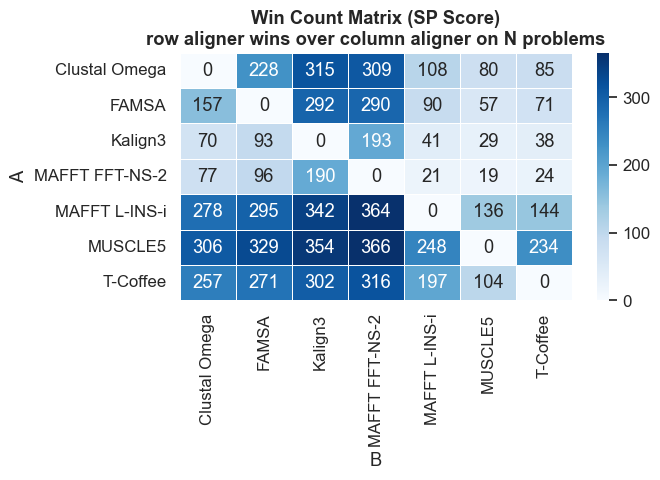

In [20]:
wide_sp = df.pivot_table(index='problem', columns='aligner', values='sp_score')

wtl_rows = []
for a1 in ALIGNERS:
    for a2 in ALIGNERS:
        if a1 == a2:
            continue
        paired = wide_sp[[a1, a2]].dropna()
        diff   = paired[a1] - paired[a2]
        wins   = (diff > 1e-6).sum()
        ties   = (diff.abs() <= 1e-6).sum()
        losses = (diff < -1e-6).sum()
        wtl_rows.append({'A': ALIGNER_LABELS[a1], 'B': ALIGNER_LABELS[a2],
                         'Win': wins, 'Tie': ties, 'Loss': losses})

df_wtl = pd.DataFrame(wtl_rows)
print('Win/Tie/Loss for SP score (row aligner vs column aligner):')
display(df_wtl)

# Heatmap of wins
win_mat = df_wtl.pivot(index='A', columns='B', values='Win').fillna(0)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(win_mat, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax)
ax.set_title('Win Count Matrix (SP Score)\nrow aligner wins over column aligner on N problems',
             fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig12_win_matrix.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig12_win_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Average Rank by Reference Set

Mean rank per RV set (1 = best):


aligner,MAFFT FFT-NS-2,MAFFT L-INS-i,MUSCLE5,Clustal Omega,Kalign3,T-Coffee,FAMSA
RV11,6.03,3.53,1.76,4.71,5.53,2.55,3.87
RV12,6.11,3.55,2.24,4.02,5.55,2.27,4.26
RV20,5.71,2.30,2.09,3.87,5.95,2.88,4.46
RV30,4.95,2.12,2.30,3.53,5.45,3.42,4.92
RV40,6.02,2.63,2.55,3.20,5.49,3.36,4.45
RV50,5.52,2.23,1.61,4.32,6.35,2.64,4.90
Overall,5.77,2.84,2.11,3.97,5.67,2.75,4.40


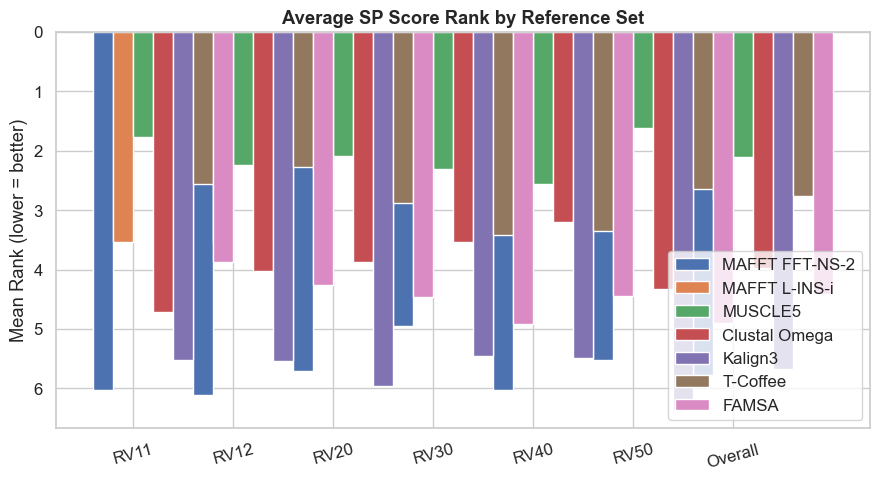

In [21]:
# Rank aligners 1 (best) to N (worst) per problem on SP score, then average per RV set
wide_sp = df.pivot_table(index='problem', columns='aligner', values='sp_score')
# rank ascending=False so rank 1 = highest score
ranks = wide_sp.rank(axis=1, ascending=False, method='average')
ranks['rv_set'] = df.drop_duplicates('problem').set_index('problem')['rv_set']

mean_ranks = ranks.groupby('rv_set')[ALIGNERS].mean().rename(columns=ALIGNER_LABELS)
overall    = ranks[ALIGNERS].mean().rename(ALIGNER_LABELS).to_frame('Overall').T
mean_ranks = pd.concat([mean_ranks, overall])

print('Mean rank per RV set (1 = best):')
display(mean_ranks.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(mean_ranks))
width = 0.2
for i, (key, label) in enumerate(ALIGNER_LABELS.items()):
    ax.bar(x + i*width, mean_ranks[label], width, label=label, color=PALETTE[key])

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(mean_ranks.index, rotation=15)
ax.set_ylabel('Mean Rank (lower = better)')
ax.set_title('Average SP Score Rank by Reference Set', fontweight='bold')
ax.invert_yaxis()
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig13_avg_rank.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig13_avg_rank.png', dpi=150, bbox_inches='tight')
plt.show()

## Critical Difference Diagram (Nemenyi, α=0.05)

Ranks aligners across all problems; horizontal brackets connect pairs not significantly different at the chosen threshold.

Mean ranks: {'Clustal Omega': 4.125, 'FAMSA': 4.441, 'Kalign3': 5.682, 'MAFFT FFT-NS-2': 5.9, 'MAFFT L-INS-i': 2.977, 'MUSCLE5': 2.116, 'T-Coffee': 2.76}
Critical Difference (Î±=0.05): 0.488


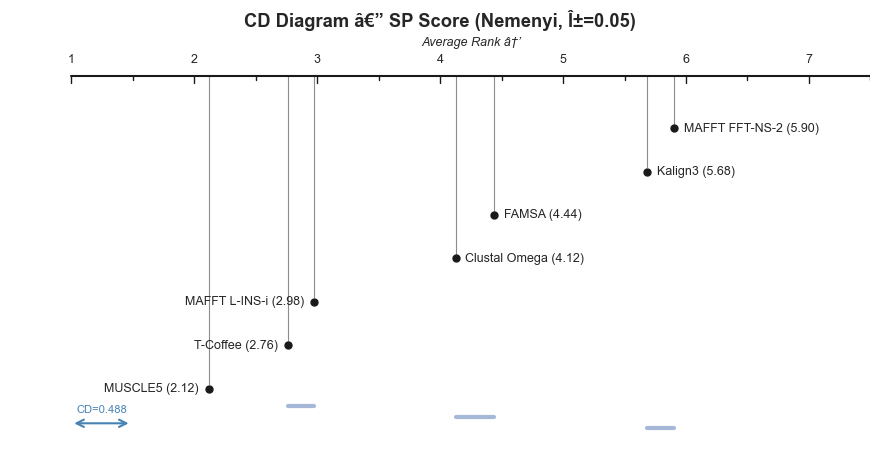

In [22]:
from scipy.stats import studentized_range

def critical_difference(n_classifiers, n_datasets, alpha=0.05):
    """Nemenyi CD using the studentized range distribution."""
    qa = studentized_range.ppf(1 - alpha, n_classifiers, df=np.inf) / np.sqrt(2)
    return qa * np.sqrt(n_classifiers * (n_classifiers + 1) / (6 * n_datasets))

def draw_cd_diagram(mean_ranks_dict, cd, title='Critical Difference Diagram'):
    """Draws a standard CD diagram (left = best rank)."""
    names  = list(mean_ranks_dict.keys())
    ranks  = list(mean_ranks_dict.values())
    pairs  = sorted(zip(ranks, names))
    n      = len(names)
    max_r  = n + 0.5

    fig, ax = plt.subplots(figsize=(9, 3 + n * 0.25))
    ax.set_xlim(0.5, max_r)
    ax.set_ylim(-1, n + 1)
    ax.axis('off')

    # Axis line
    ax.plot([1, max_r], [n + 0.5, n + 0.5], 'k-', lw=1.5)
    for r in np.arange(1, n + 1, 0.5):
        h = 0.15 if r == int(r) else 0.08
        ax.plot([r, r], [n + 0.5 - h, n + 0.5], 'k-', lw=1)
        if r == int(r):
            ax.text(r, n + 0.75, str(int(r)), ha='center', va='bottom', fontsize=9)

    ax.text((1 + max_r) / 2, n + 1.2, 'Average Rank â†’', ha='center', fontsize=9, style='italic')

    # Aligner labels + tick lines
    for i, (rank, name) in enumerate(pairs):
        y = i + 0.3
        ax.plot([rank, rank], [n + 0.5, y + 0.1], 'k-', lw=0.8, alpha=0.5)
        ax.plot(rank, y, 'ko', ms=5)
        ha = 'right' if rank <= (n + 1) / 2 else 'left'
        offset = -0.08 if ha == 'right' else 0.08
        ax.text(rank + offset, y, f'{name} ({rank:.2f})', ha=ha, va='center', fontsize=9)

    # CD bar in top-left corner
    bar_x = 1.0
    bar_y = -0.5
    ax.annotate('', xy=(bar_x + cd, bar_y), xytext=(bar_x, bar_y),
                arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.5))
    ax.text(bar_x + cd / 2, bar_y + 0.25, f'CD={cd:.3f}', ha='center', fontsize=8, color='steelblue')

    # Draw cliques (connected groups not significantly different)
    sorted_ranks = [r for r, _ in pairs]
    used = set()
    clique_y = -0.1
    for i in range(len(pairs)):
        clique = [i]
        for j in range(i + 1, len(pairs)):
            if sorted_ranks[j] - sorted_ranks[i] < cd:
                clique.append(j)
        if len(clique) > 1 and tuple(clique) not in used:
            used.add(tuple(clique))
            ax.plot([sorted_ranks[clique[0]], sorted_ranks[clique[-1]]],
                    [clique_y, clique_y], 'b-', lw=3, alpha=0.5)
            clique_y -= 0.25

    ax.set_title(title, fontweight='bold', pad=20)
    return fig

# Compute mean ranks across ALL problems
wide_sp_all = df.pivot_table(index='problem', columns='aligner', values='sp_score').dropna()
n_probs     = len(wide_sp_all)
mean_r      = wide_sp_all.rank(axis=1, ascending=False, method='average').mean()
cd_val      = critical_difference(len(ALIGNERS), n_probs, alpha=0.05)

mean_r_named = {ALIGNER_LABELS[k]: round(v, 3) for k, v in mean_r.items()}
print(f'Mean ranks: {mean_r_named}')
print(f'Critical Difference (Î±=0.05): {cd_val:.3f}')

fig = draw_cd_diagram(mean_r_named, cd_val, title='CD Diagram â€” SP Score (Nemenyi, Î±=0.05)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig14_cd_diagram.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig14_cd_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

## Exact Nemenyi Post-hoc p-values

Pairwise exact Friedman rank-sum p-values (Eisinga et al., *BMC Bioinformatics* 2017). More powerful than Bonferroni on ranks; pairs sharing a clique in the CD diagram should not be significant here.

Exact Nemenyi p-values (SP Score, N=341 complete problems):


,MAFFT FFT-NS-2,MAFFT L-INS-i,MUSCLE5,Clustal Omega,Kalign3,T-Coffee,FAMSA
MAFFT FFT-NS-2,1.0000,0.0000,0.0000,0.0000,0.8426,0.0000,0.0000
MAFFT L-INS-i,0.0000,1.0000,0.0000,0.0000,0.0000,0.8468,0.0000
MUSCLE5,0.0000,0.0000,1.0000,0.0000,0.0000,0.0019,0.0000
Clustal Omega,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.4706
Kalign3,0.8426,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
T-Coffee,0.0000,0.8468,0.0019,0.0000,0.0000,1.0000,0.0000
FAMSA,0.0000,0.0000,0.0000,0.4706,0.0000,0.0000,1.0000


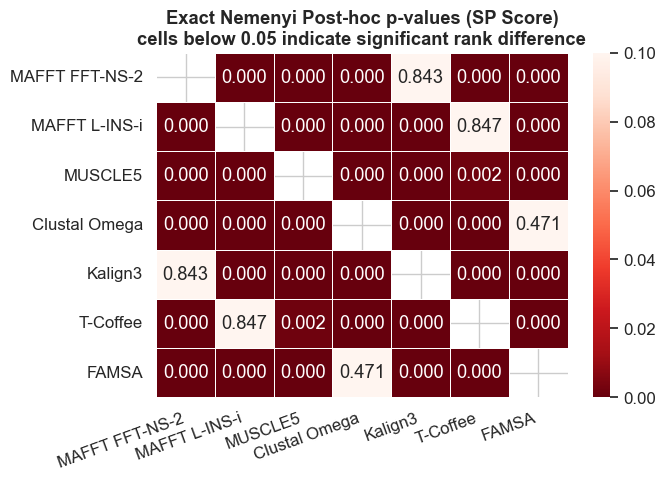

In [23]:
import scikit_posthocs as sp

# Exact Nemenyi test on SP scores (complete cases only)
wide_sp_nem = df.pivot_table(index='problem', columns='aligner',
                              values='sp_score').dropna()

# scikit-posthocs expects a DataFrame; returns a symmetric p-value matrix
nem_p = sp.posthoc_nemenyi_friedman(wide_sp_nem[ALIGNERS])
nem_p.index   = [ALIGNER_LABELS[a] for a in ALIGNERS]
nem_p.columns = [ALIGNER_LABELS[a] for a in ALIGNERS]

print(f'Exact Nemenyi p-values (SP Score, N={len(wide_sp_nem)} complete problems):')
display(nem_p.round(4))
nem_p.to_csv(PROJECT_DIR / 'results' / 'table_nemenyi_sp.csv')

# Visualise as a heatmap
fig, ax = plt.subplots(figsize=(7, 5))
mask = np.eye(len(ALIGNERS), dtype=bool)
sns.heatmap(nem_p, annot=True, fmt='.3f', cmap='Reds_r',
            vmin=0, vmax=0.1, linewidths=0.5,
            mask=mask, ax=ax)
ax.set_title('Exact Nemenyi Post-hoc p-values (SP Score)\n'
             'cells below 0.05 indicate significant rank difference',
             fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig20_nemenyi_heatmap.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig20_nemenyi_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Parallel Coordinates — SP Score per Problem

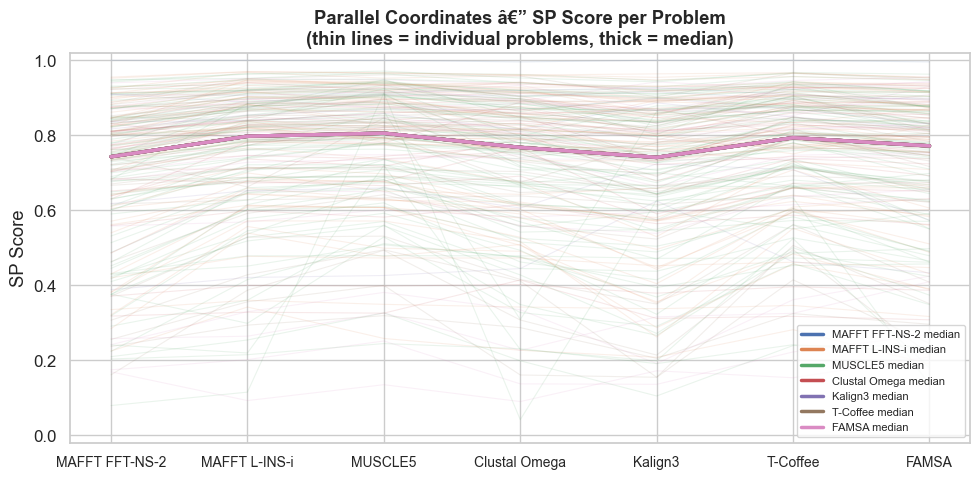

In [24]:
# One line per problem; each axis is an aligner; y = SP score.
# Helps reveal which problems flip rankings.
wide_sp_pc = df.pivot_table(index='problem', columns='aligner', values='sp_score').dropna()
wide_sp_pc = wide_sp_pc[ALIGNERS].rename(columns=ALIGNER_LABELS)

# Color by dominant aligner (which one scored highest)
dominant = wide_sp_pc.idxmax(axis=1)
dom_colors = {label: PALETTE[key] for key, label in ALIGNER_LABELS.items()}

fig, ax = plt.subplots(figsize=(10, 5))
col_names = list(wide_sp_pc.columns)
x_pos = range(len(col_names))

# Thin lines for all problems (subsample if > 200)
sample = wide_sp_pc.sample(min(200, len(wide_sp_pc)), random_state=42)
for _, row in sample.iterrows():
    dom = dominant[row.name]
    ax.plot(x_pos, row.values, color=dom_colors[dom], alpha=0.12, lw=0.8)

# Median lines per aligner (thick)
for key, label in ALIGNER_LABELS.items():
    medians = wide_sp_pc.median()
    ax.plot(x_pos, medians.values, color=PALETTE[key], lw=2.5,
            label=f'{label} median', zorder=5)

ax.set_xticks(x_pos)
ax.set_xticklabels(col_names, fontsize=10)
ax.set_ylabel('SP Score')
ax.set_ylim(-0.02, 1.02)
ax.set_title('Parallel Coordinates â€” SP Score per Problem\n(thin lines = individual problems, thick = median)',
             fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig15_parallel_coords.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig15_parallel_coords.png', dpi=150, bbox_inches='tight')
plt.show()

## Wilcoxon Tests on Runtime

Same matched-pair framework as the accuracy tests. Rank-biserial *r* is the effect size companion (analogous to Cliff's delta for accuracy).

In [25]:
def rank_biserial_r(x, y):
    """Rank-biserial correlation as Wilcoxon effect size."""
    n    = len(x)
    stat, _ = stats.wilcoxon(x, y)
    return 1 - (4 * stat) / (n * (n + 1))

rt_wide = df.pivot_table(index='problem', columns='aligner', values='runtime_sec')
rt_rows = []
for a1, a2 in combinations(ALIGNERS, 2):
    if a1 not in rt_wide.columns or a2 not in rt_wide.columns:
        continue
    paired = rt_wide[[a1, a2]].dropna()
    if len(paired) < 5:
        continue
    stat, pval = stats.wilcoxon(paired[a1], paired[a2], alternative='two-sided')
    r = rank_biserial_r(paired[a1].values, paired[a2].values)
    rt_rows.append({
        'aligner_1':       ALIGNER_LABELS[a1],
        'aligner_2':       ALIGNER_LABELS[a2],
        'n_pairs':         len(paired),
        'W_stat':          round(stat, 2),
        'p_value':         round(pval, 6),
        'significant':     pval < 0.05,
        'rank_biserial_r': round(r, 4),
    })

df_rt = pd.DataFrame(rt_rows)
print("Wilcoxon signed-rank tests on runtime differences:")
display(df_rt)
df_rt.to_csv(PROJECT_DIR / 'results' / 'table_wilcoxon_runtime.csv', index=False)


Wilcoxon signed-rank tests on runtime differences:


,aligner_1,aligner_2,n_pairs,W_stat,p_value,significant,rank_biserial_r
0,MAFFT FFT-NS-2,MAFFT L-INS-i,386,2114.0,0.000000,True,0.9434
1,MAFFT FFT-NS-2,MUSCLE5,386,25415.0,0.000000,True,0.3195
2,MAFFT FFT-NS-2,Clustal Omega,386,22865.0,0.000000,True,0.3877
3,MAFFT FFT-NS-2,Kalign3,386,0.0,0.000000,True,1.0000
4,MAFFT FFT-NS-2,T-Coffee,342,0.0,0.000000,True,1.0000
5,MAFFT FFT-NS-2,FAMSA,386,11297.0,0.000000,True,0.6975
6,MAFFT L-INS-i,MUSCLE5,386,17252.0,0.000000,True,0.5380
7,MAFFT L-INS-i,Clustal Omega,386,5563.0,0.000000,True,0.8510
8,MAFFT L-INS-i,Kalign3,386,0.0,0.000000,True,1.0000
9,MAFFT L-INS-i,T-Coffee,342,0.0,0.000000,True,1.0000


## Δ SP Score Heatmap

Mean pairwise SP difference (row aligner − MAFFT FFT-NS-2 baseline) per reference set. A diverging palette makes directionality immediately legible.

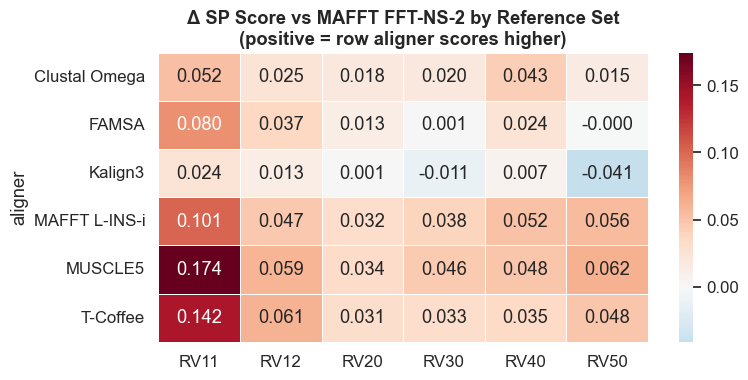

In [26]:
baseline_key = 'mafft_fftns2'
baseline_lbl = ALIGNER_LABELS[baseline_key]

delta_rows = []
for rv in RV_SETS:
    rv_wide = df[df['rv_set'] == rv].pivot_table(
        index='problem', columns='aligner', values='sp_score')
    for a1 in ALIGNERS:
        if a1 == baseline_key:
            continue
        if a1 not in rv_wide.columns or baseline_key not in rv_wide.columns:
            continue
        paired = rv_wide[[a1, baseline_key]].dropna()
        delta_rows.append({
            'rv_set':  rv,
            'aligner': ALIGNER_LABELS[a1],
            'delta':   (paired[a1] - paired[baseline_key]).mean(),
        })

delta_pivot = (pd.DataFrame(delta_rows)
               .pivot_table(index='aligner', columns='rv_set', values='delta')
               .reindex(columns=RV_SETS))

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(delta_pivot, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax)
ax.set_title(f'Δ SP Score vs {baseline_lbl} by Reference Set\n'
             '(positive = row aligner scores higher)', fontweight='bold')
ax.set_xlabel('')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig18_delta_sp_heatmap.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig18_delta_sp_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Bootstrap 95% CIs per Reference Set

Per-subset uncertainty on mean SP; useful when sub-group sample sizes differ (RV11 has 76 problems, RV50 only 31).

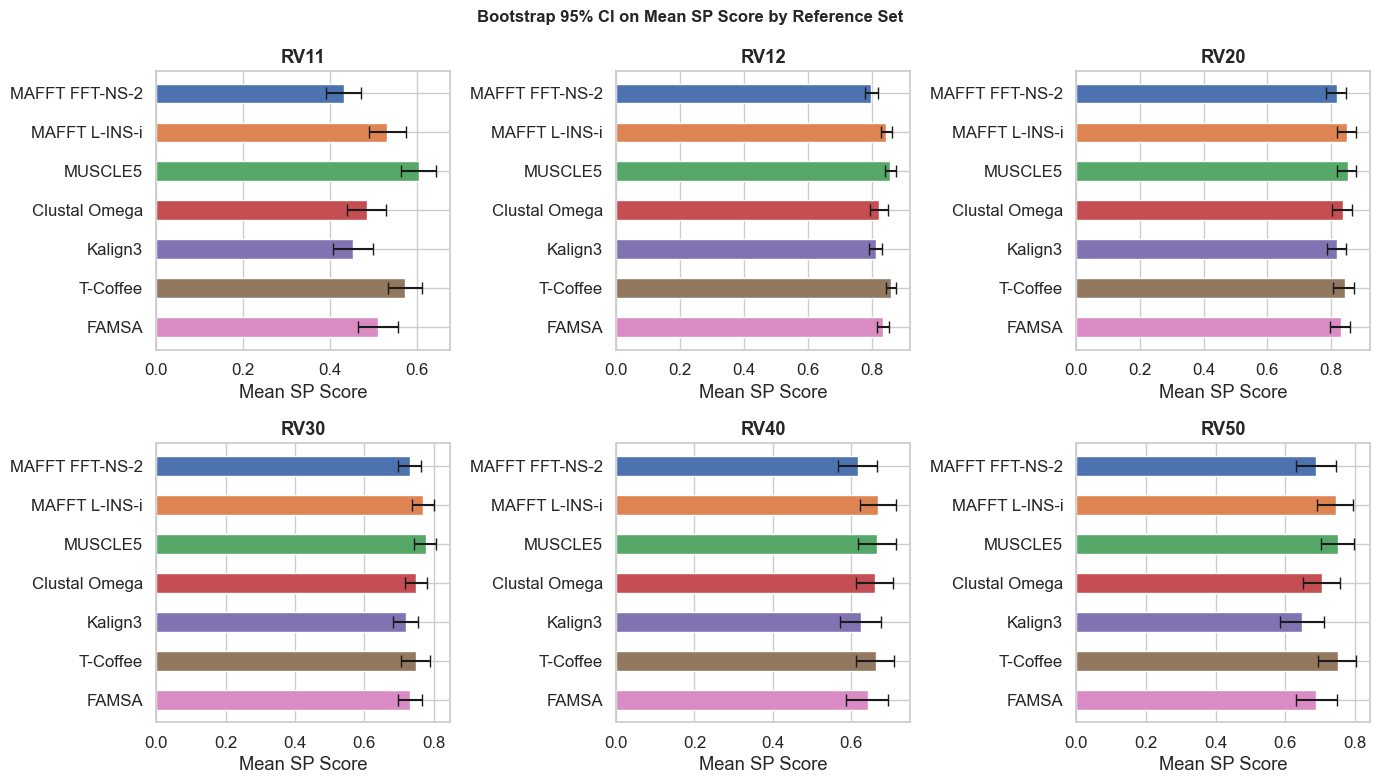

In [27]:
rng2   = np.random.default_rng(0)
N_BOOT = 2000

bv_rows = []
for rv in RV_SETS:
    for key, label in ALIGNER_LABELS.items():
        vals = df[(df['aligner'] == key) & (df['rv_set'] == rv)]['sp_score'].dropna().values
        if len(vals) < 3:
            continue
        boot_means = [rng2.choice(vals, size=len(vals), replace=True).mean()
                      for _ in range(N_BOOT)]
        lo, hi = np.percentile(boot_means, [2.5, 97.5])
        bv_rows.append({'rv_set': rv, 'aligner': label,
                        'sp_mean': vals.mean(), 'ci_lo': lo, 'ci_hi': hi})

df_bv = pd.DataFrame(bv_rows)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
for ax, rv in zip(axes.flat, RV_SETS):
    rv_data = df_bv[df_bv['rv_set'] == rv].reset_index(drop=True)
    for _, row in rv_data.iterrows():
        key = next(k for k, v in ALIGNER_LABELS.items() if v == row['aligner'])
        ax.barh(row['aligner'], row['sp_mean'],
                xerr=[[row['sp_mean'] - row['ci_lo']], [row['ci_hi'] - row['sp_mean']]],
                color=PALETTE[key], capsize=4, height=0.5)
    ax.set_title(rv, fontweight='bold')
    ax.set_xlabel('Mean SP Score')
    ax.invert_yaxis()

fig.suptitle('Bootstrap 95% CI on Mean SP Score by Reference Set',
             fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig19_bootstrap_ci_per_rv.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig19_bootstrap_ci_per_rv.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Computational Scaling

Sequence count and mean length parsed from `.tfa` input files; correlated with runtime and peak memory.

In [28]:
from Bio import SeqIO

meta_rows = []
for rv in RV_SETS:
    rv_dir = BB3_DIR / rv
    for tfa in rv_dir.glob('*.tfa'):
        seqs = list(SeqIO.parse(str(tfa), 'fasta'))
        if not seqs:
            continue
        lengths = [len(str(s.seq).replace('-','').replace('.','')) for s in seqs]
        meta_rows.append({
            'problem':   tfa.stem,
            'rv_set':    rv,
            'n_seqs':    len(seqs),
            'mean_len':  np.mean(lengths),
            'max_len':   max(lengths),
        })

df_meta = pd.DataFrame(meta_rows)
print(f'Problem metadata: {len(df_meta)} entries')
display(df_meta.describe().round(1))

# Merge into main df
df2 = df.merge(df_meta[['problem','n_seqs','mean_len']], on='problem', how='left')

c:\Users\anand\AppData\Local\Programs\Python\Python311\Lib\site-packages\Bio\__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: c:\Users\anand\AppData\Local\Programs\Python\Python311\Lib\site-packages
  warnings.warn(


Problem metadata: 386 entries


,n_seqs,mean_len,max_len
count,386.0,386.0,386.0
mean,28.7,338.3,575.7
std,27.4,210.3,662.0
min,4.0,43.6,49.0
25%,8.0,195.8,237.5
50%,18.0,308.6,415.0
75%,42.0,460.9,694.8
max,142.0,1630.1,7923.0


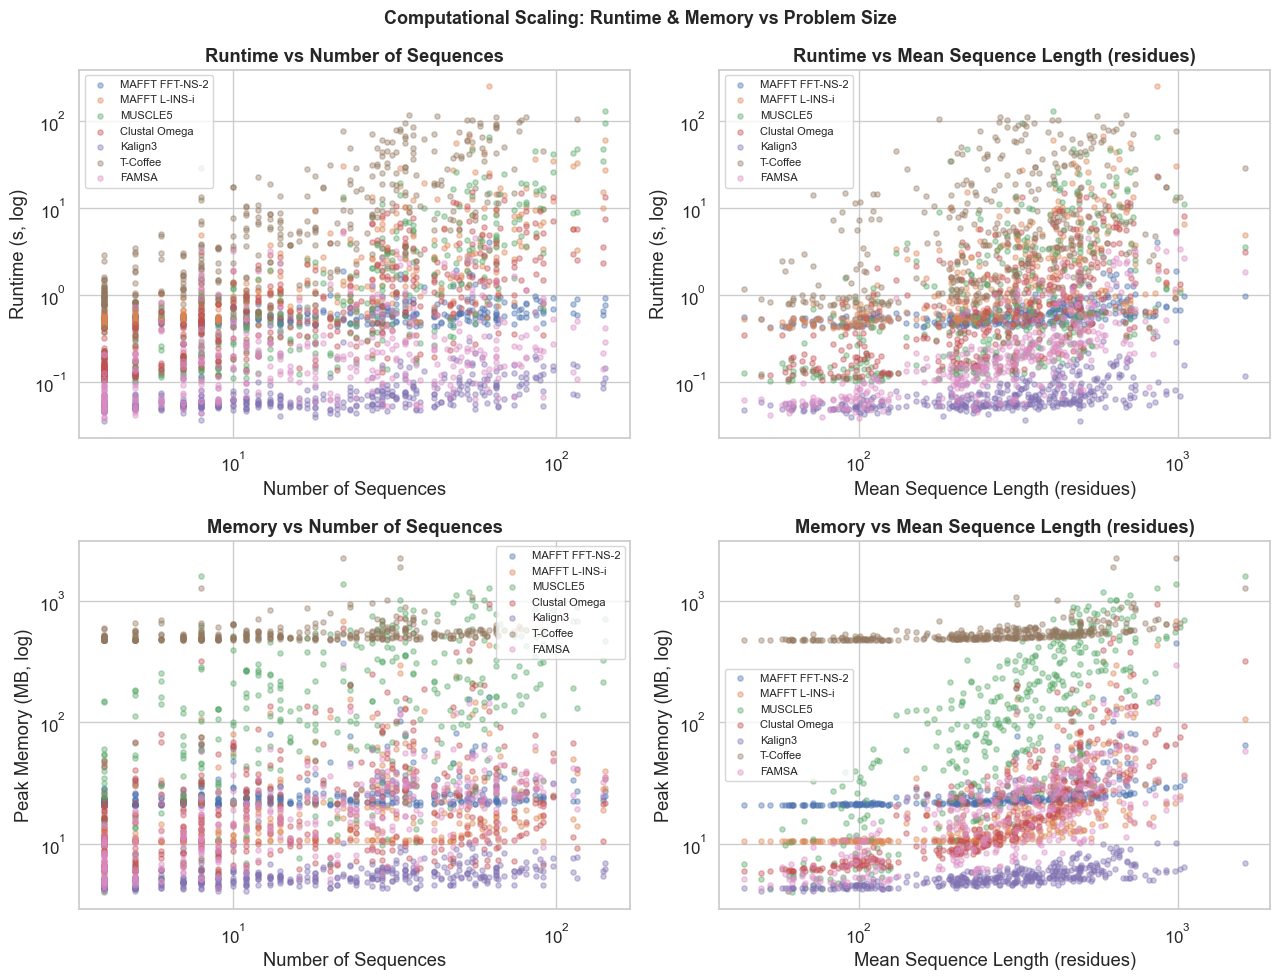

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, (x_col, x_label) in zip(axes[0], [('n_seqs', 'Number of Sequences'),
                                            ('mean_len', 'Mean Sequence Length (residues)')]):
    for key, label in ALIGNER_LABELS.items():
        sub = df2[df2['aligner'] == key][[x_col, 'runtime_sec']].dropna()
        ax.scatter(sub[x_col], sub['runtime_sec'],
                   color=PALETTE[key], alpha=0.4, s=14, label=label)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(x_label); ax.set_ylabel('Runtime (s, log)')
    ax.set_title(f'Runtime vs {x_label}', fontweight='bold')
    ax.legend(fontsize=8)

for ax, (x_col, x_label) in zip(axes[1], [('n_seqs', 'Number of Sequences'),
                                            ('mean_len', 'Mean Sequence Length (residues)')]):
    for key, label in ALIGNER_LABELS.items():
        sub = df2[df2['aligner'] == key][[x_col, 'peak_mem_mb']].dropna()
        ax.scatter(sub[x_col], sub['peak_mem_mb'],
                   color=PALETTE[key], alpha=0.4, s=14, label=label)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(x_label); ax.set_ylabel('Peak Memory (MB, log)')
    ax.set_title(f'Memory vs {x_label}', fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Computational Scaling: Runtime & Memory vs Problem Size', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig16_scaling_plots.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig16_scaling_plots.png', dpi=150, bbox_inches='tight')
plt.show()

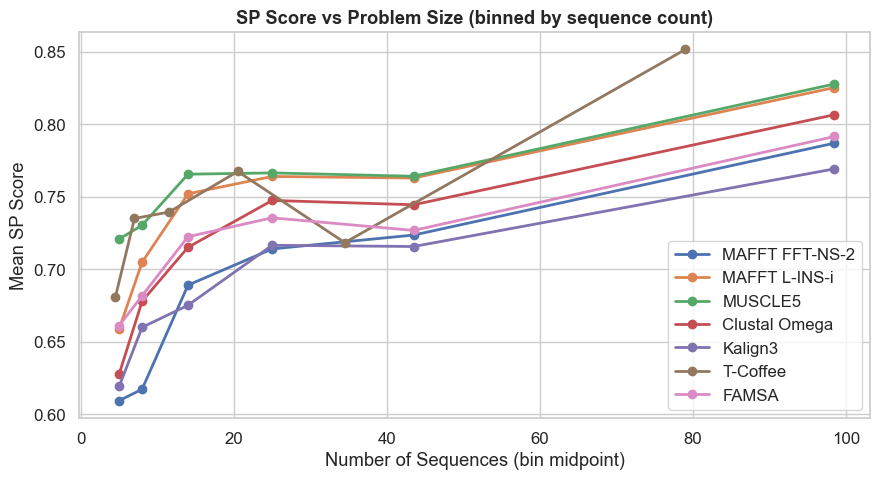

In [30]:
# Score drop vs problem size (n_seqs)
fig, ax = plt.subplots(figsize=(9, 5))
for key, label in ALIGNER_LABELS.items():
    sub = df2[df2['aligner'] == key][['n_seqs', 'sp_score']].dropna()
    # bin by n_seqs quartiles for clarity
    sub = sub.copy()
    sub['size_bin'] = pd.qcut(sub['n_seqs'], q=6, duplicates='drop')
    grouped = sub.groupby('size_bin', observed=True)['sp_score'].mean()
    bin_centers = [interval.mid for interval in grouped.index]
    ax.plot(bin_centers, grouped.values, marker='o', color=PALETTE[key], label=label, lw=2)

ax.set_xlabel('Number of Sequences (bin midpoint)')
ax.set_ylabel('Mean SP Score')
ax.set_title('SP Score vs Problem Size (binned by sequence count)', fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig17_score_vs_size.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig17_score_vs_size.png', dpi=150, bbox_inches='tight')
plt.show()

## Score vs Mean Pairwise Identity

Mean pairwise sequence identity is parsed from the BAliBASE `.xml` reference files (reference alignment columns, gap-excluded). Lower identity = more divergent sequences = harder problem. Standard plot in every MSA paper.

Identity computed for 386 problems.
count    386.000
mean       0.290
std        0.087
min        0.121
25%        0.221
50%        0.291
75%        0.340
max        0.602
Name: mean_pairwise_id, dtype: float64


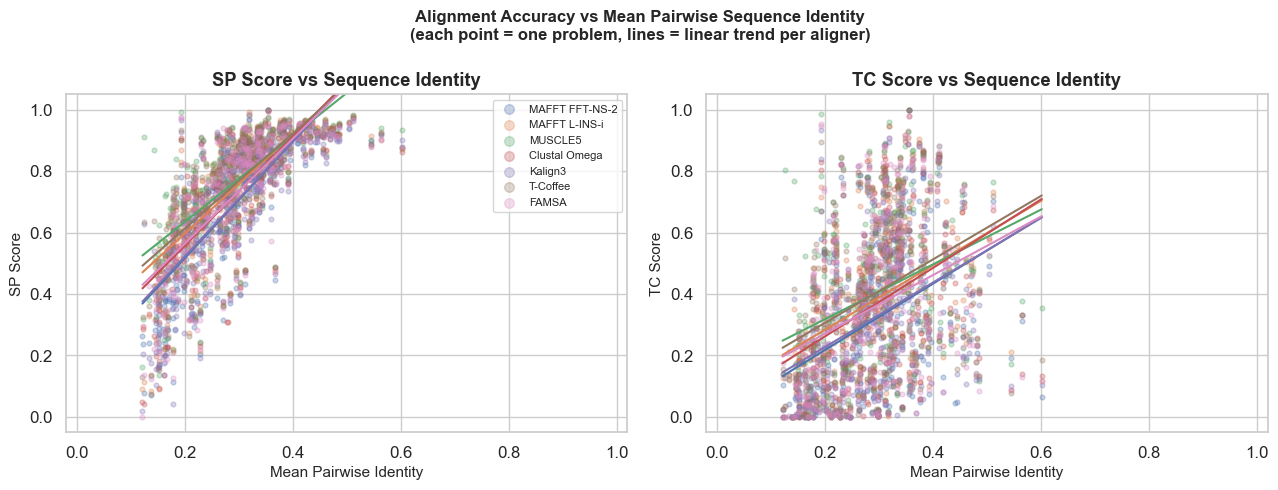


Spearman ρ (identity vs SP) per aligner:
  MAFFT FFT-NS-2        ρ=0.840  p=6.39e-104
  MAFFT L-INS-i         ρ=0.805  p=3.41e-89
  MUSCLE5               ρ=0.761  p=3.65e-74
  Clustal Omega         ρ=0.809  p=8.96e-91
  Kalign3               ρ=0.806  p=3.00e-89
  T-Coffee              ρ=0.772  p=7.49e-69
  FAMSA                 ρ=0.780  p=2.66e-80


In [31]:
import xml.etree.ElementTree as ET
from itertools import combinations as _comb

GAP = set('-. ~')

def pairwise_identity(seq_a, seq_b):
    """
    Fraction of aligned columns where both sequences have a residue and
    they match.  Denominator = columns where both are non-gap.
    """
    matches = shared = 0
    for a, b in zip(seq_a, seq_b):
        if a not in GAP and b not in GAP:
            shared += 1
            if a.upper() == b.upper():
                matches += 1
    return matches / shared if shared else 0.0

def mean_identity_from_xml(xml_path):
    """Parse BAliBASE XML and return mean pairwise identity over all sequence pairs."""
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    seqs = []
    for seq_el in root.iter('sequence'):
        data = seq_el.find('seq-data')
        if data is not None and data.text:
            seqs.append(data.text.strip().replace('\n', '').replace(' ', ''))
    if len(seqs) < 2:
        return None
    ids = [pairwise_identity(a, b) for a, b in _comb(seqs, 2)]
    return sum(ids) / len(ids)

# Build identity lookup for every problem
identity_map = {}
for rv in RV_SETS:
    for xml_path in (BB3_DIR / rv).glob('*.xml'):
        pid = xml_path.stem
        val = mean_identity_from_xml(xml_path)
        if val is not None:
            identity_map[pid] = val

df_id = pd.DataFrame(list(identity_map.items()), columns=['problem', 'mean_pairwise_id'])
print(f'Identity computed for {len(df_id)} problems.')
print(df_id['mean_pairwise_id'].describe().round(3))

df3 = df.merge(df_id, on='problem', how='left')

# Plot SP score vs mean pairwise identity per aligner
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, ylabel in zip(axes,
                               ['sp_score', 'tc_score'],
                               ['SP Score', 'TC Score']):
    for key, label in ALIGNER_LABELS.items():
        sub = df3[df3['aligner'] == key][['mean_pairwise_id', metric]].dropna()
        ax.scatter(sub['mean_pairwise_id'], sub[metric],
                   color=PALETTE[key], alpha=0.3, s=12, label=label)
        # Trend line
        if len(sub) > 5:
            z = np.polyfit(sub['mean_pairwise_id'], sub[metric], 1)
            xs = np.linspace(sub['mean_pairwise_id'].min(),
                             sub['mean_pairwise_id'].max(), 100)
            ax.plot(xs, np.poly1d(z)(xs), color=PALETTE[key], lw=1.5)

    ax.set_xlabel('Mean Pairwise Identity', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{ylabel} vs Sequence Identity', fontweight='bold')
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.05, 1.05)
    if ax is axes[0]:
        ax.legend(fontsize=8, markerscale=2)

fig.suptitle('Alignment Accuracy vs Mean Pairwise Sequence Identity\n'
             '(each point = one problem, lines = linear trend per aligner)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig21_score_vs_identity.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig21_score_vs_identity.png', dpi=150, bbox_inches='tight')
plt.show()

# Spearman correlation: identity vs SP per aligner
print('\nSpearman ρ (identity vs SP) per aligner:')
for key, label in ALIGNER_LABELS.items():
    sub = df3[df3['aligner'] == key][['mean_pairwise_id', 'sp_score']].dropna()
    rho, p = stats.spearmanr(sub['mean_pairwise_id'], sub['sp_score'])
    print(f'  {label:<20}  ρ={rho:.3f}  p={p:.2e}')


---
## Failure Analysis

Which problems failed, which aligner failed them, and what characteristics (sequence count, length, reference set) do they share?

In [32]:
df_all_raw = pd.read_csv(CSV_PATH)
failures   = df_all_raw[df_all_raw['success'] != True].copy()

print(f'Total failures: {len(failures)} / {len(df_all_raw)} ({100*len(failures)/len(df_all_raw):.1f}%)')

if len(failures) > 0:
    print('\nFailures by aligner:')
    display(failures.groupby('aligner').size().rename('n_failures'))
    print('\nFailures by RV set:')
    display(failures.groupby('rv_set').size().rename('n_failures'))

    failures_meta = failures.merge(df_meta[['problem','n_seqs','mean_len']], on='problem', how='left')
    print('\nFailed problem characteristics:')
    display(failures_meta[['problem','rv_set','aligner','n_seqs','mean_len']].sort_values('n_seqs'))
else:
    print('\nNo failures â€” all 1,544 runs succeeded.')

# Score distribution on "hard" problems (bottom 10% SP across all aligners)
mean_sp_per_prob = df.groupby('problem')['sp_score'].mean()
hard_threshold   = mean_sp_per_prob.quantile(0.10)
hard_problems    = mean_sp_per_prob[mean_sp_per_prob <= hard_threshold].index

hard_df = df[df['problem'].isin(hard_problems)].merge(
    df_meta[['problem','n_seqs','mean_len']], on='problem', how='left')

print(f'\n"Hard" problems (bottom 10% mean SP, threshold={hard_threshold:.3f}): {len(hard_problems)}')
display(hard_df.groupby('aligner')[['sp_score','n_seqs','mean_len']].mean().round(3)
        .rename(index=ALIGNER_LABELS))

Total failures: 44 / 2702 (1.6%)

Failures by aligner:


aligner
t_coffee    44
Name: n_failures, dtype: int64


Failures by RV set:


rv_set
RV20    15
RV30    22
RV40     4
RV50     3
Name: n_failures, dtype: int64


Failed problem characteristics:


,problem,rv_set,aligner,n_seqs,mean_len
31,BB20010,RV20,t_coffee,29,1044.448276
27,BBS20017,RV20,t_coffee,45,560.133333
42,BB20017,RV20,t_coffee,45,652.822222
29,BB20041,RV20,t_coffee,48,695.375000
20,BB50012,RV50,t_coffee,49,707.755102
23,BB30004,RV30,t_coffee,50,497.260000
39,BB30010,RV30,t_coffee,50,655.540000
40,BBS30010,RV30,t_coffee,50,554.740000
38,BB20021,RV20,t_coffee,53,692.339623
11,BB40047,RV40,t_coffee,54,581.759259



"Hard" problems (bottom 10% mean SP, threshold=0.441): 39


,sp_score,n_seqs,mean_len
aligner,,,
Clustal Omega,0.315,14.949,322.969
FAMSA,0.320,14.949,322.969
Kalign3,0.275,14.949,322.969
MAFFT FFT-NS-2,0.272,14.949,322.969
MAFFT L-INS-i,0.343,14.949,322.969
MUSCLE5,0.412,14.949,322.969
T-Coffee,0.388,13.895,315.353
